UMAP Clustering Visualization

**Goal**: Visualize the 113-dimensional feature space in 2D to see:
- How well normal and distress meows separate
- If there are distinct clusters
- Which cats are similar to each other
- Potential outliers or misclassified examples

In [ ]:
# Google Colab Setup
try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive')
    print("✓ Google Drive mounted")
except:
    print("✓ Running locally")

GDRIVE_BASE = '/content/drive/MyDrive/Electric Sheep/Beliz - EDA'

# Install UMAP
print("Installing UMAP...")
!pip install -q umap-learn
print("✓ UMAP installed")

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import umap
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported")

# Setup paths
PROJECT_ROOT = Path(GDRIVE_BASE)
DATA_DIR = PROJECT_ROOT / "data"
FEATURES_DIR = DATA_DIR / "features"
FIGURES_DIR = PROJECT_ROOT / "figures"

Mounted at /content/drive
✓ Google Drive mounted
Installing UMAP...
✓ UMAP installed
✓ Libraries imported


# Nowa sekcja

In [ ]:
# Load feature data
features_path = FEATURES_DIR / "features_all.csv"
df_features = pd.read_csv(features_path)

print(f"✓ Loaded {len(df_features)} samples")
print(f"  Features shape: {df_features.shape}")

# Separate features from metadata
metadata_cols = ['filename', 'cat_id', 'context', 'distress_label',
                 'breed', 'sex', 'split', 'index']
metadata_cols = [col for col in metadata_cols if col in df_features.columns]

feature_cols = [col for col in df_features.columns if col not in metadata_cols]

print(f"  Feature columns: {len(feature_cols)}")

# Extract features and labels
X = df_features[feature_cols].values
y = df_features['distress_label'].values

print(f"\nFeature matrix: {X.shape}")
print(f"Labels: {y.shape}")
print(f"  Normal (0): {(y == 0).sum()}")
print(f"  Distress (1): {(y == 1).sum()}")

# Scale Features -> UMAP works better with scaled features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"✓ Features scaled")
print(f"  Mean: {X_scaled.mean():.4f}")
print(f"  Std: {X_scaled.std():.4f}")

✓ Loaded 440 samples
  Features shape: (440, 121)
  Feature columns: 113

Feature matrix: (440, 113)
Labels: (440,)
  Normal (0): 219
  Distress (1): 221
✓ Features scaled
  Mean: -0.0000
  Std: 1.0000


In [ ]:
# Run UMAP

print("=" * 70)
print("RUNNING UMAP")
print("=" * 70)

# Initialize UMAP
reducer = umap.UMAP(
    n_neighbors=15,      # Number of neighbors (15-50 typical)
    min_dist=0.1,        # Minimum distance (0.0-1.0)
    n_components=2,      # Reduce to 2D for visualization
    metric='euclidean',
    random_state=42
)

print("\nFitting UMAP (this may take 1-2 minutes)...")
X_umap = reducer.fit_transform(X_scaled)

print(f"✓ UMAP complete!")
print(f"  Original dimensions: {X_scaled.shape[1]}")
print(f"  Reduced dimensions: {X_umap.shape[1]}")
print(f"  Output shape: {X_umap.shape}")

RUNNING UMAP

Fitting UMAP (this may take 1-2 minutes)...
✓ UMAP complete!
  Original dimensions: 113
  Reduced dimensions: 2
  Output shape: (440, 2)



VISUALIZATION 1: DISTRESS VS NORMAL


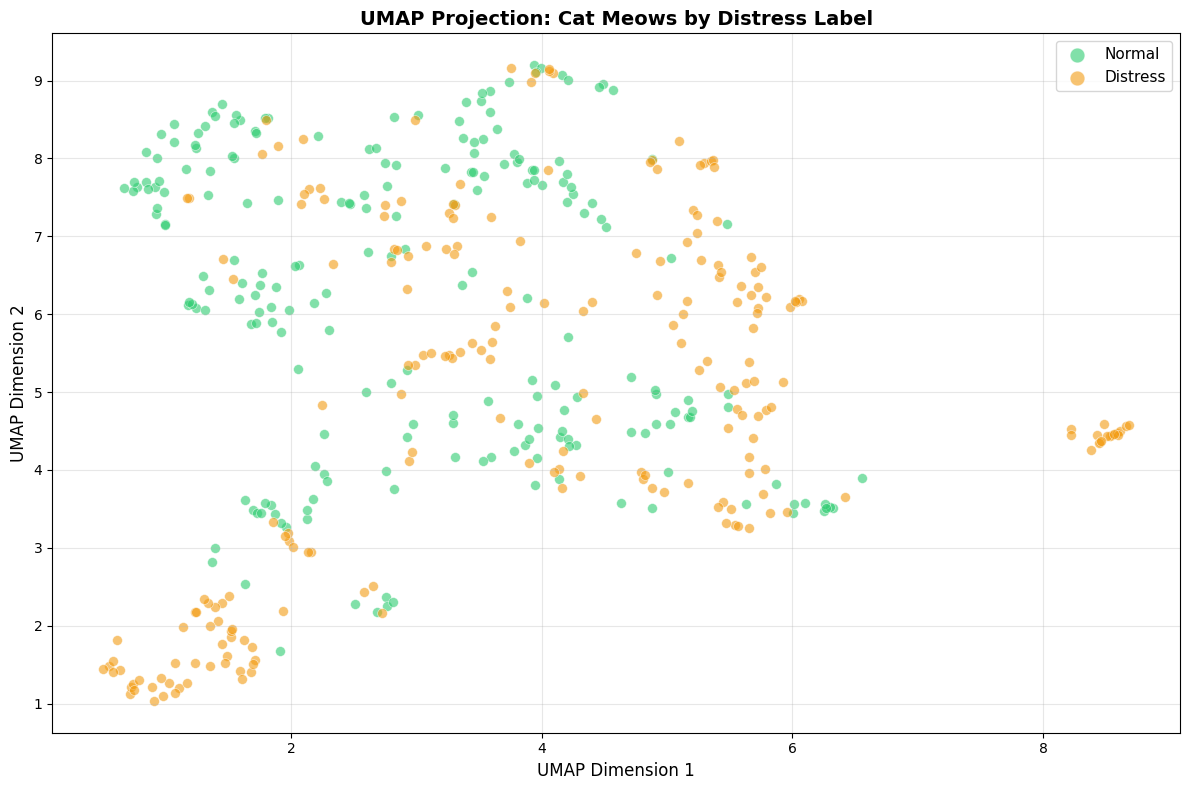

✓ Saved: umap_01_distress_vs_normal.png

Cluster Statistics:
  Normal center: (3.02, 6.20)
  Distress center: (3.91, 4.86)
  Separation distance: 1.61


In [ ]:
# Visualize UMAP: Distress vs Normal

print("\n" + "=" * 70)
print("VISUALIZATION 1: DISTRESS VS NORMAL")
print("=" * 70)

fig, ax = plt.subplots(figsize=(12, 8))

# Plot by distress label
colors = {0: '#2ECC71', 1: '#F39C12'}  # Green for normal, orange for distress
labels_map = {0: 'Normal', 1: 'Distress'}

for label in [0, 1]:
    mask = y == label
    ax.scatter(
        X_umap[mask, 0],
        X_umap[mask, 1],
        c=colors[label],
        label=labels_map[label],
        alpha=0.6,
        s=50,
        edgecolors='white',
        linewidth=0.5
    )

ax.set_xlabel('UMAP Dimension 1', fontsize=12)
ax.set_ylabel('UMAP Dimension 2', fontsize=12)
ax.set_title('UMAP Projection: Cat Meows by Distress Label',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, markerscale=1.5)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'umap_01_distress_vs_normal.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: umap_01_distress_vs_normal.png")

# Calculate separation
normal_center = X_umap[y == 0].mean(axis=0)
distress_center = X_umap[y == 1].mean(axis=0)
separation = np.linalg.norm(normal_center - distress_center)

print(f"\nCluster Statistics:")
print(f"  Normal center: ({normal_center[0]:.2f}, {normal_center[1]:.2f})")
print(f"  Distress center: ({distress_center[0]:.2f}, {distress_center[1]:.2f})")
print(f"  Separation distance: {separation:.2f}")


VISUALIZATION 2: BY CONTEXT (B/F/I)


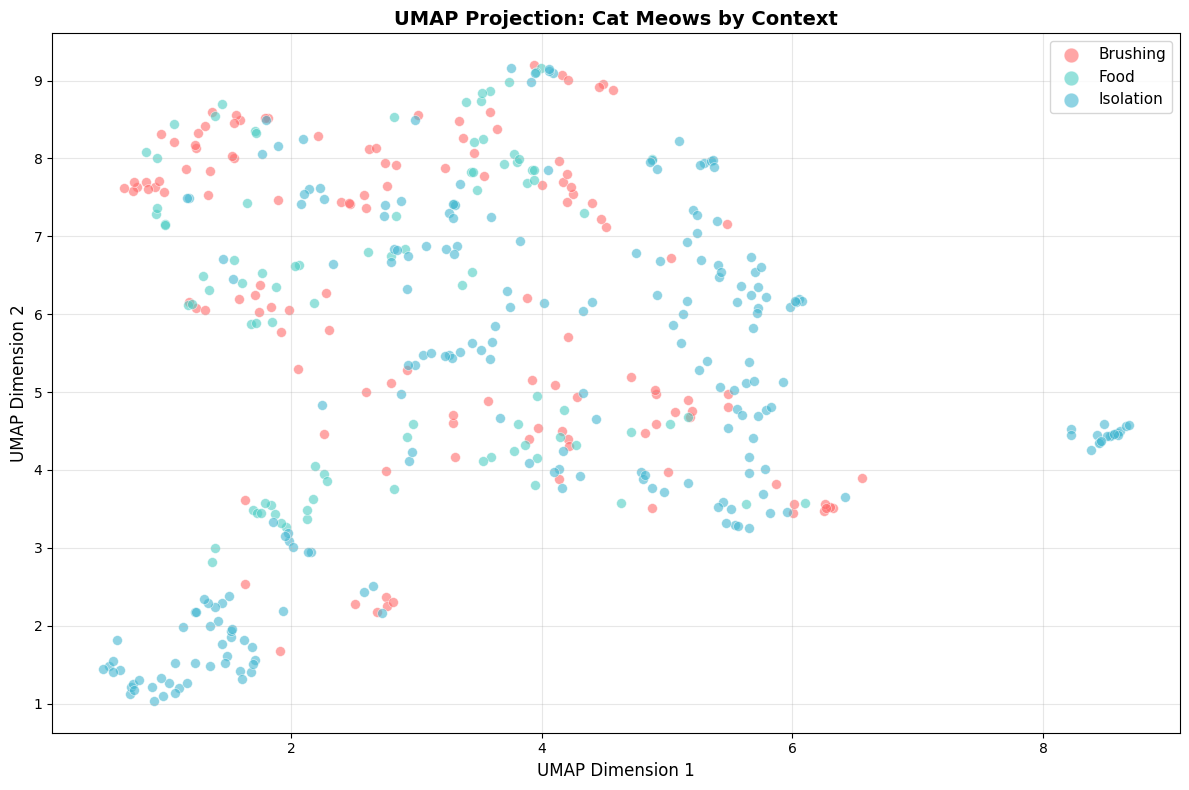

✓ Saved: umap_02_by_context.png


In [ ]:
# Visualize UMAP: By Context

print("\n" + "=" * 70)
print("VISUALIZATION 2: BY CONTEXT (B/F/I)")
print("=" * 70)

if 'context' in df_features.columns:
    fig, ax = plt.subplots(figsize=(12, 8))

    # Plot by context
    context_colors = {'B': '#FF6B6B', 'F': '#4ECDC4', 'I': '#45B7D1'}
    context_names = {'B': 'Brushing', 'F': 'Food', 'I': 'Isolation'}

    for context in ['B', 'F', 'I']:
        mask = df_features['context'] == context
        ax.scatter(
            X_umap[mask, 0],
            X_umap[mask, 1],
            c=context_colors[context],
            label=context_names[context],
            alpha=0.6,
            s=50,
            edgecolors='white',
            linewidth=0.5
        )

    ax.set_xlabel('UMAP Dimension 1', fontsize=12)
    ax.set_ylabel('UMAP Dimension 2', fontsize=12)
    ax.set_title('UMAP Projection: Cat Meows by Context',
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=11, markerscale=1.5)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'umap_02_by_context.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✓ Saved: umap_02_by_context.png")


VISUALIZATION 3: BY CAT (COLOR-CODED)


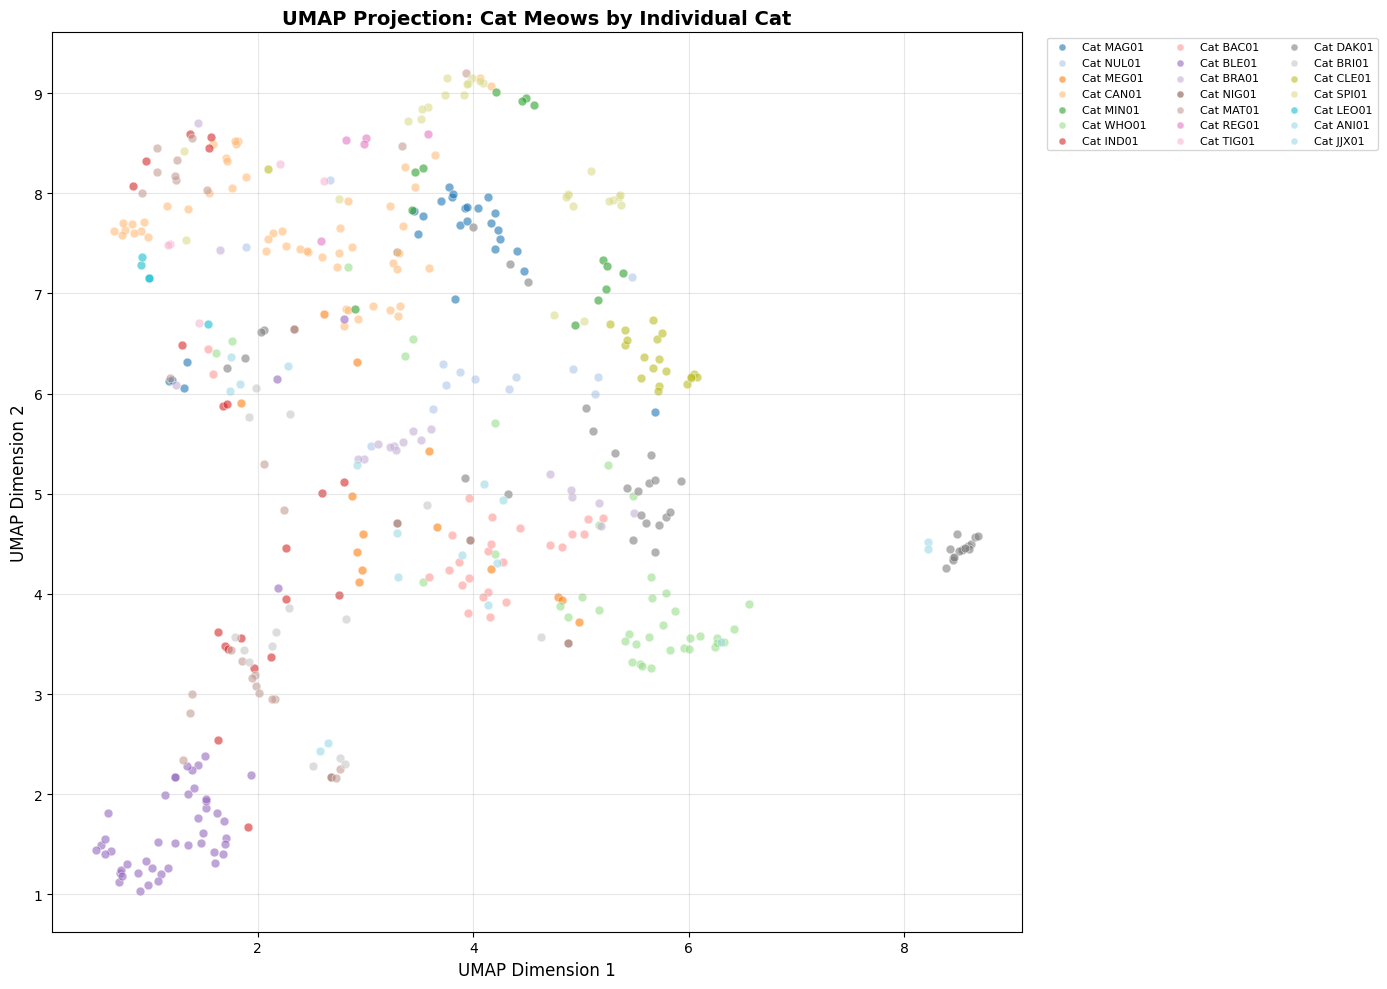

✓ Saved: umap_03_by_cat.png


In [ ]:
# Visualize UMAP: By Cat ID

print("\n" + "=" * 70)
print("VISUALIZATION 3: BY CAT (COLOR-CODED)")
print("=" * 70)

if 'cat_id' in df_features.columns:
    fig, ax = plt.subplots(figsize=(14, 10))

    # Get unique cats
    unique_cats = df_features['cat_id'].unique()
    n_cats = len(unique_cats)

    # Generate colors for each cat
    colors = plt.cm.tab20(np.linspace(0, 1, n_cats))

    # Plot each cat
    for i, cat_id in enumerate(unique_cats):
        mask = df_features['cat_id'] == cat_id
        ax.scatter(
            X_umap[mask, 0],
            X_umap[mask, 1],
            c=[colors[i]],
            label=f'Cat {cat_id}',
            alpha=0.6,
            s=40,
            edgecolors='white',
            linewidth=0.5
        )

    ax.set_xlabel('UMAP Dimension 1', fontsize=12)
    ax.set_ylabel('UMAP Dimension 2', fontsize=12)
    ax.set_title('UMAP Projection: Cat Meows by Individual Cat',
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=8, ncol=3, markerscale=0.8, loc='upper left',
              bbox_to_anchor=(1.02, 1))
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'umap_03_by_cat.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✓ Saved: umap_03_by_cat.png")


VISUALIZATION 4: BY BREED


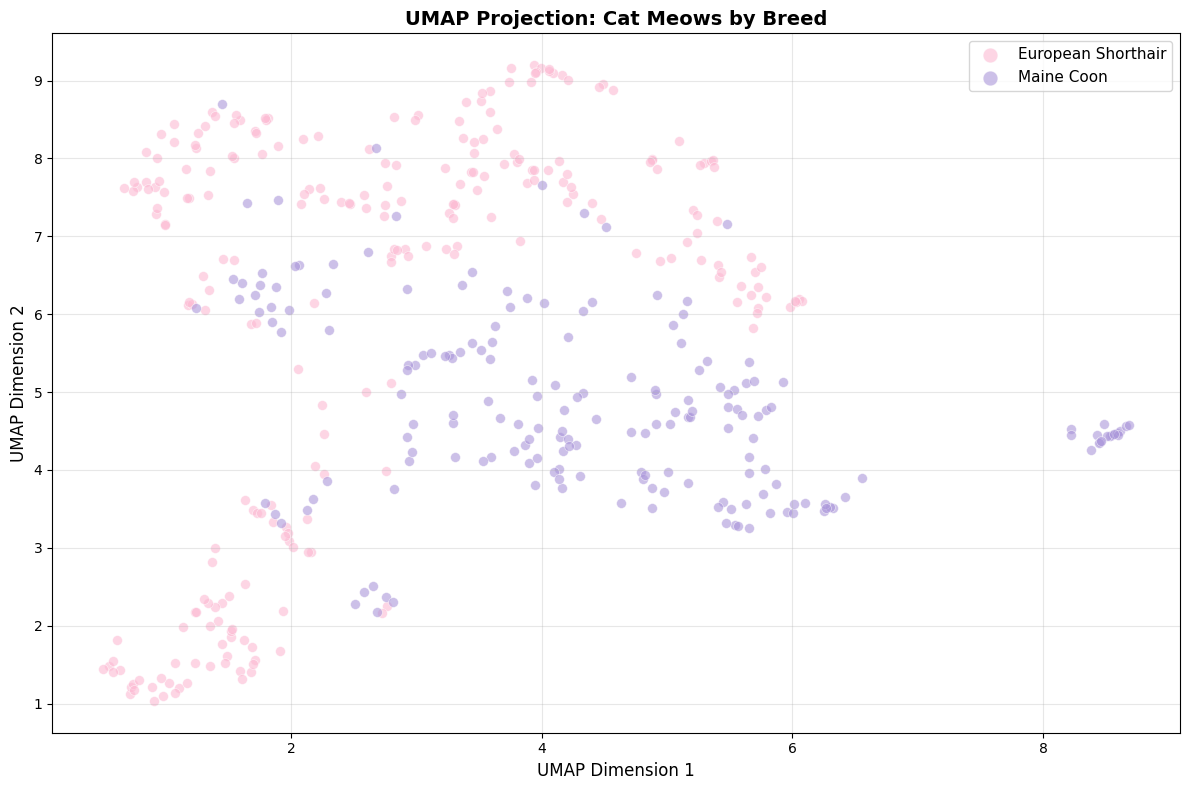

✓ Saved: umap_04_by_breed.png


In [ ]:
# Visualize UMAP: By Breed

print("\n" + "=" * 70)
print("VISUALIZATION 4: BY BREED")
print("=" * 70)

if 'breed' in df_features.columns:
    fig, ax = plt.subplots(figsize=(12, 8))

    # Plot by breed
    breed_colors = {'MC': '#AA96DA', 'EU': '#FCBAD3'}
    breed_names = {'MC': 'Maine Coon', 'EU': 'European Shorthair'}

    for breed in df_features['breed'].unique():
        if breed in breed_colors:
            mask = df_features['breed'] == breed
            ax.scatter(
                X_umap[mask, 0],
                X_umap[mask, 1],
                c=breed_colors[breed],
                label=breed_names.get(breed, breed),
                alpha=0.6,
                s=50,
                edgecolors='white',
                linewidth=0.5
            )

    ax.set_xlabel('UMAP Dimension 1', fontsize=12)
    ax.set_ylabel('UMAP Dimension 2', fontsize=12)
    ax.set_title('UMAP Projection: Cat Meows by Breed',
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=11, markerscale=1.5)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'umap_04_by_breed.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✓ Saved: umap_04_by_breed.png")


VISUALIZATION 5: COMBINED (DISTRESS + CONTEXT)


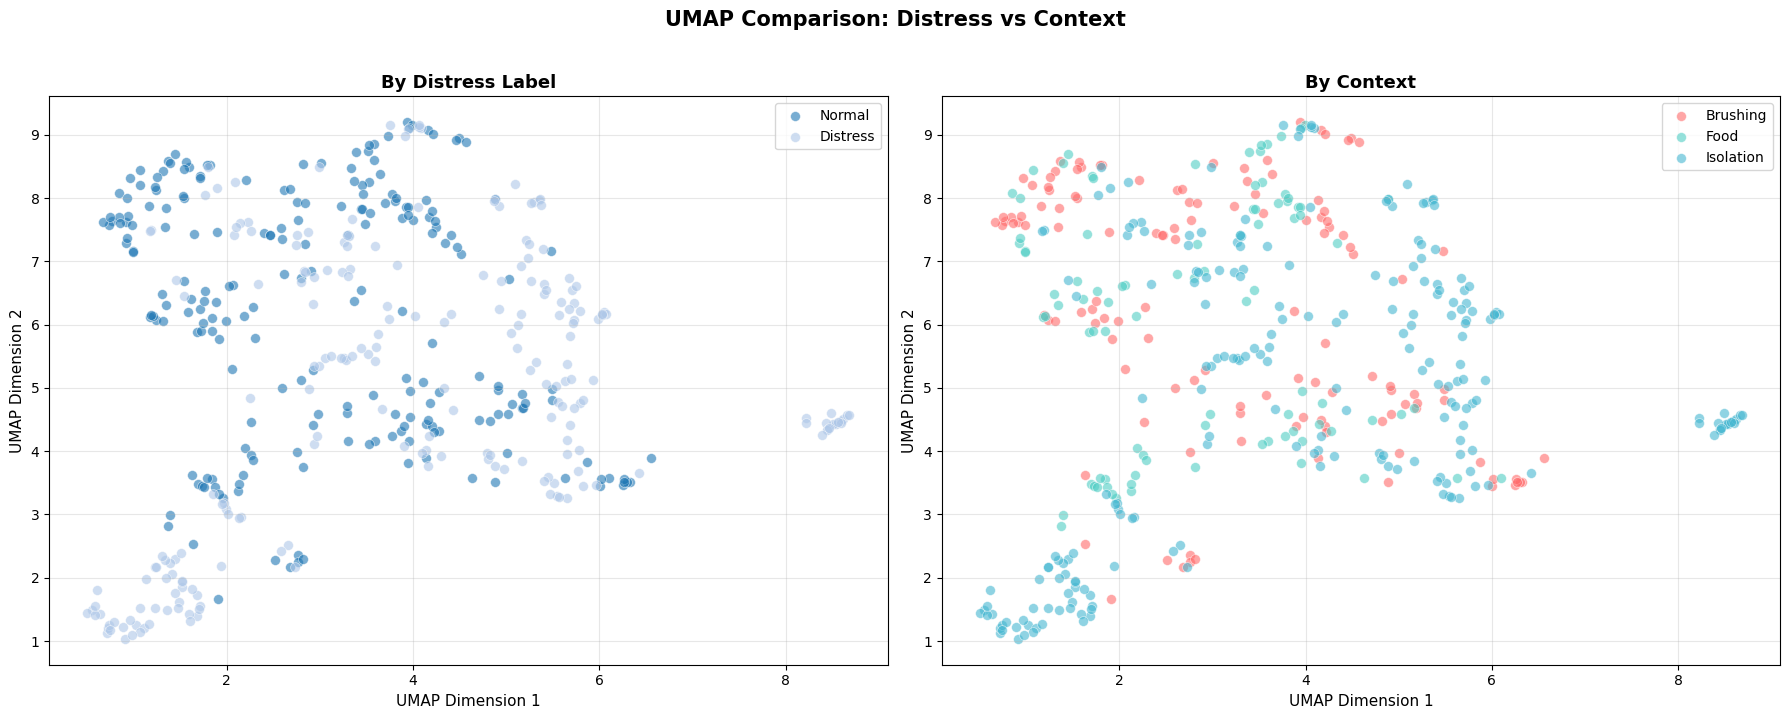

✓ Saved: umap_05_combined.png


In [ ]:
# Combined Visualization: Distress + Context

print("\n" + "=" * 70)
print("VISUALIZATION 5: COMBINED (DISTRESS + CONTEXT)")
print("=" * 70)

if 'context' in df_features.columns:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Left plot: By distress
    for label in [0, 1]:
        mask = y == label
        axes[0].scatter(
            X_umap[mask, 0],
            X_umap[mask, 1],
            c=colors[label],
            label=labels_map[label],
            alpha=0.6,
            s=50,
            edgecolors='white',
            linewidth=0.5
        )

    axes[0].set_xlabel('UMAP Dimension 1', fontsize=11)
    axes[0].set_ylabel('UMAP Dimension 2', fontsize=11)
    axes[0].set_title('By Distress Label', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(alpha=0.3)

    # Right plot: By context
    for context in ['B', 'F', 'I']:
        mask = df_features['context'] == context
        axes[1].scatter(
            X_umap[mask, 0],
            X_umap[mask, 1],
            c=context_colors[context],
            label=context_names[context],
            alpha=0.6,
            s=50,
            edgecolors='white',
            linewidth=0.5
        )

    axes[1].set_xlabel('UMAP Dimension 1', fontsize=11)
    axes[1].set_ylabel('UMAP Dimension 2', fontsize=11)
    axes[1].set_title('By Context', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(alpha=0.3)

    plt.suptitle('UMAP Comparison: Distress vs Context',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'umap_05_combined.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✓ Saved: umap_05_combined.png")


VISUALIZATION 6: 3D UMAP (INTERACTIVE)
Fitting 3D UMAP...
✓ 3D UMAP complete: (440, 3)


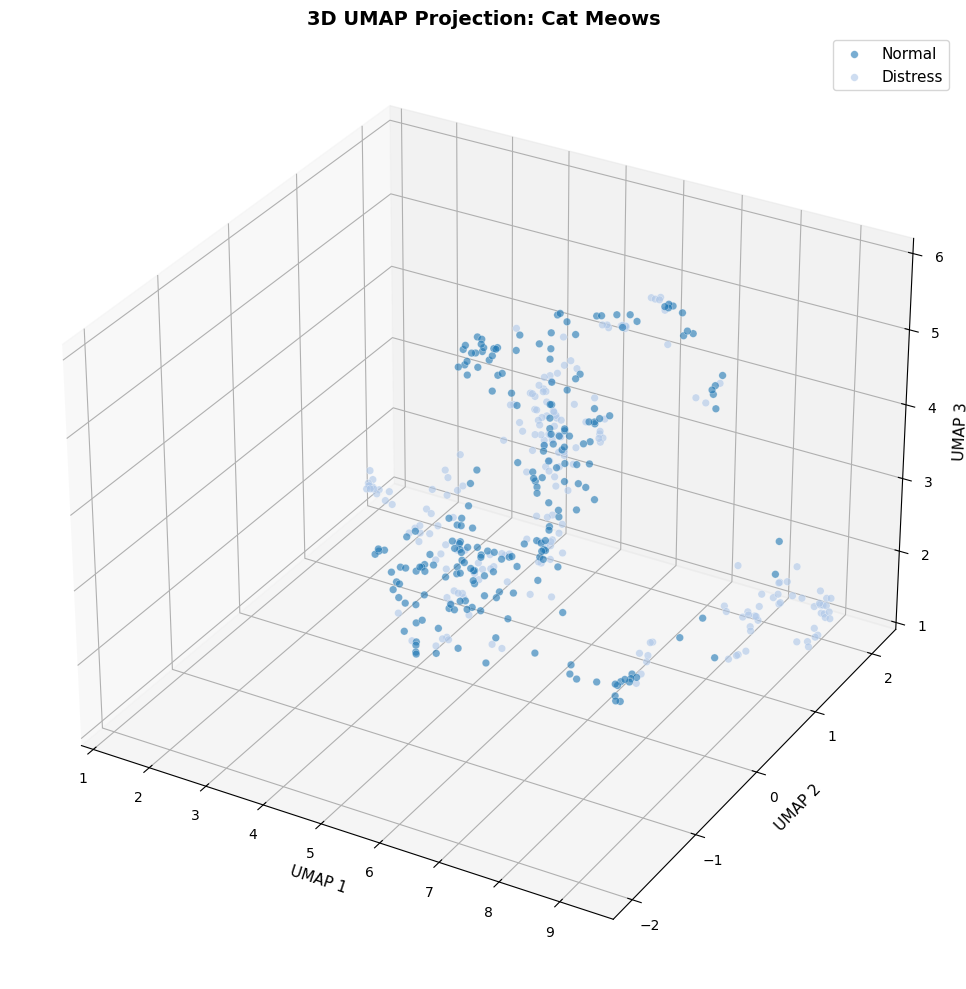

✓ Saved: umap_06_3d.png


In [ ]:
# Interactive 3D UMAP

print("\n" + "=" * 70)
print("VISUALIZATION 6: 3D UMAP (INTERACTIVE)")
print("=" * 70)

# Run 3D UMAP
reducer_3d = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=3,  # 3D instead of 2D
    metric='euclidean',
    random_state=42
)

print("Fitting 3D UMAP...")
X_umap_3d = reducer_3d.fit_transform(X_scaled)

print(f"✓ 3D UMAP complete: {X_umap_3d.shape}")

# Create 3D plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot by distress label
for label in [0, 1]:
    mask = y == label
    ax.scatter(
        X_umap_3d[mask, 0],
        X_umap_3d[mask, 1],
        X_umap_3d[mask, 2],
        c=colors[label],
        label=labels_map[label],
        alpha=0.6,
        s=30,
        edgecolors='white',
        linewidth=0.3
    )

ax.set_xlabel('UMAP 1', fontsize=11)
ax.set_ylabel('UMAP 2', fontsize=11)
ax.set_zlabel('UMAP 3', fontsize=11)
ax.set_title('3D UMAP Projection: Cat Meows', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'umap_06_3d.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: umap_06_3d.png")


OUTLIER ANALYSIS

Top 5 Normal Outliers (farthest from normal cluster center):
  1. B_WHO01_MC_FI_SIM01_302.wav
     Cat: WHO01, Context: B, Distance: 4.22
  2. B_WHO01_MC_FI_SIM01_102.wav
     Cat: WHO01, Context: B, Distance: 4.23
  3. B_ANI01_MC_FN_SIM01_101.wav
     Cat: ANI01, Context: B, Distance: 4.24
  4. B_WHO01_MC_FI_SIM01_103.wav
     Cat: WHO01, Context: B, Distance: 4.26
  5. B_IND01_EU_FN_ELI01_103.wav
     Cat: IND01, Context: B, Distance: 4.66

Top 5 Distress Outliers (farthest from distress cluster center):
  1. I_BLE01_EU_FN_DEL01_215.wav
     Cat: BLE01, Context: I, Distance: 4.83
  2. I_BLE01_EU_FN_DEL01_217.wav
     Cat: BLE01, Context: I, Distance: 4.84
  3. I_BLE01_EU_FN_DEL01_219.wav
     Cat: BLE01, Context: I, Distance: 4.85
  4. I_BLE01_EU_FN_DEL01_206.wav
     Cat: BLE01, Context: I, Distance: 4.86
  5. I_BLE01_EU_FN_DEL01_216.wav
     Cat: BLE01, Context: I, Distance: 4.91

VISUALIZATION 7: HIGHLIGHTING OUTLIERS


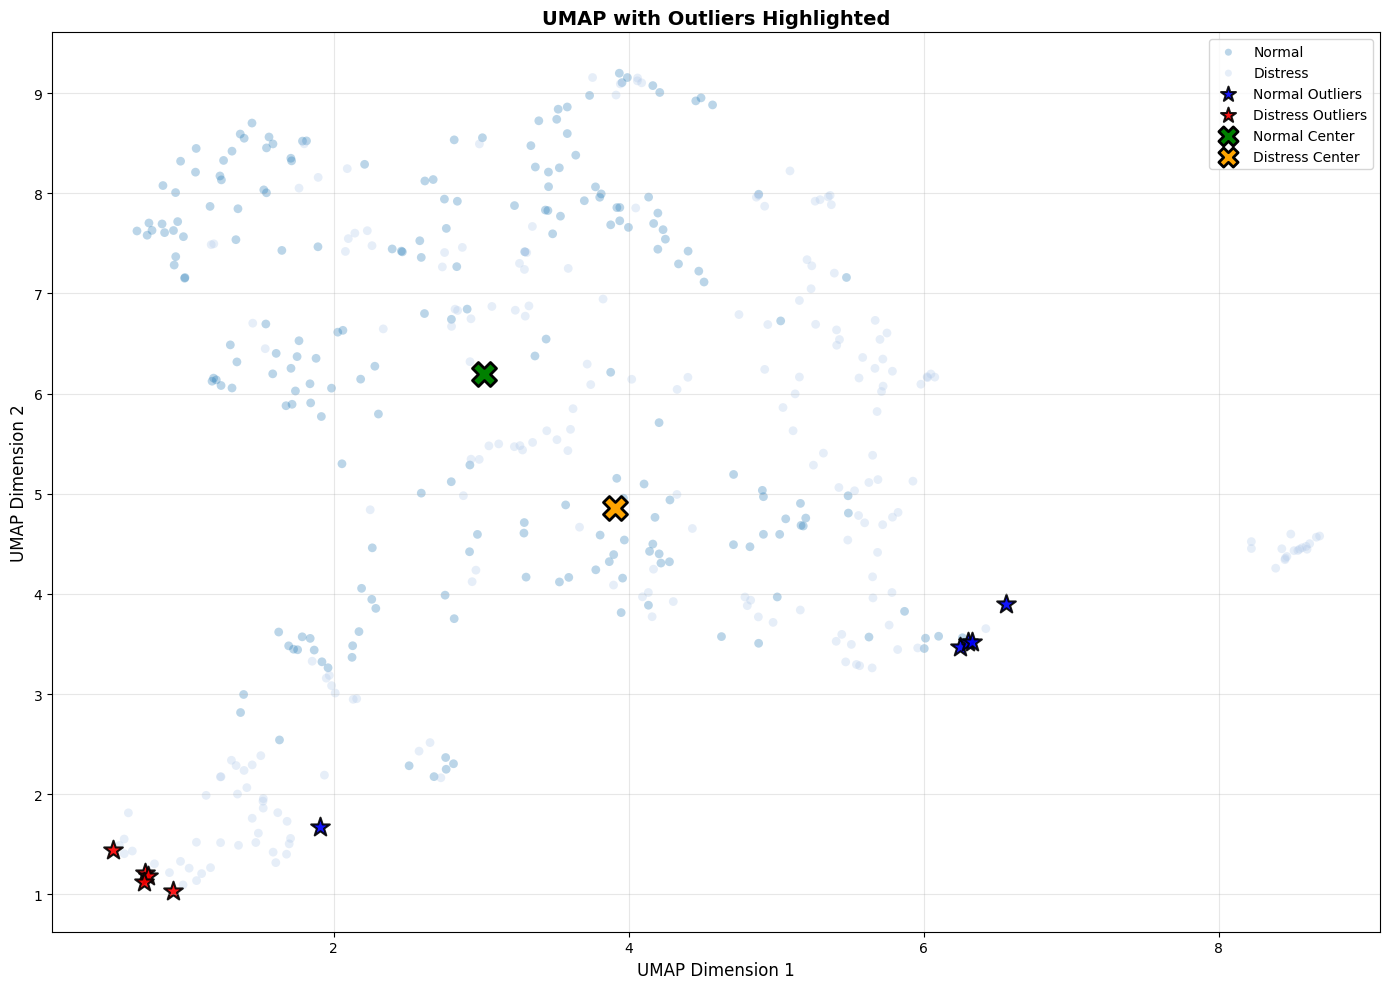

✓ Saved: umap_07_outliers.png


In [ ]:
# Identify Outliers and Interesting Cases

print("\n" + "=" * 70)
print("OUTLIER ANALYSIS")
print("=" * 70)

# Find outliers (points far from their class center)
from scipy.spatial.distance import cdist

# Calculate distance of each point to its class center
normal_mask = y == 0
distress_mask = y == 1

# Distances for normal meows
normal_distances = cdist(
    X_umap[normal_mask],
    normal_center.reshape(1, -1)
).flatten()

# Distances for distress meows
distress_distances = cdist(
    X_umap[distress_mask],
    distress_center.reshape(1, -1)
).flatten()

# Find top 5 outliers in each class
normal_indices = np.where(normal_mask)[0]
distress_indices = np.where(distress_mask)[0]

top_normal_outliers = normal_indices[np.argsort(normal_distances)[-5:]]
top_distress_outliers = distress_indices[np.argsort(distress_distances)[-5:]]

print("\nTop 5 Normal Outliers (farthest from normal cluster center):")
for i, idx in enumerate(top_normal_outliers, 1):
    print(f"  {i}. {df_features.iloc[idx]['filename']}")
    print(f"     Cat: {df_features.iloc[idx]['cat_id']}, "
          f"Context: {df_features.iloc[idx]['context']}, "
          f"Distance: {normal_distances[np.where(normal_indices == idx)[0][0]]:.2f}")

print("\nTop 5 Distress Outliers (farthest from distress cluster center):")
for i, idx in enumerate(top_distress_outliers, 1):
    print(f"  {i}. {df_features.iloc[idx]['filename']}")
    print(f"     Cat: {df_features.iloc[idx]['cat_id']}, "
          f"Context: {df_features.iloc[idx]['context']}, "
          f"Distance: {distress_distances[np.where(distress_indices == idx)[0][0]]:.2f}")

# Visualize Outliers

print("\n" + "=" * 70)
print("VISUALIZATION 7: HIGHLIGHTING OUTLIERS")
print("=" * 70)

fig, ax = plt.subplots(figsize=(14, 10))

# Plot all points in light colors
for label in [0, 1]:
    mask = y == label
    ax.scatter(
        X_umap[mask, 0],
        X_umap[mask, 1],
        c=colors[label],
        label=labels_map[label],
        alpha=0.3,
        s=40,
        edgecolors='none'
    )

# Highlight outliers
ax.scatter(
    X_umap[top_normal_outliers, 0],
    X_umap[top_normal_outliers, 1],
    c='blue',
    label='Normal Outliers',
    alpha=0.9,
    s=200,
    marker='*',
    edgecolors='black',
    linewidth=1.5
)

ax.scatter(
    X_umap[top_distress_outliers, 0],
    X_umap[top_distress_outliers, 1],
    c='red',
    label='Distress Outliers',
    alpha=0.9,
    s=200,
    marker='*',
    edgecolors='black',
    linewidth=1.5
)

# Mark centers
ax.scatter(
    normal_center[0], normal_center[1],
    c='green', marker='X', s=300,
    label='Normal Center',
    edgecolors='black',
    linewidth=2
)

ax.scatter(
    distress_center[0], distress_center[1],
    c='orange', marker='X', s=300,
    label='Distress Center',
    edgecolors='black',
    linewidth=2
)

ax.set_xlabel('UMAP Dimension 1', fontsize=12)
ax.set_ylabel('UMAP Dimension 2', fontsize=12)
ax.set_title('UMAP with Outliers Highlighted', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, markerscale=0.8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'umap_07_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: umap_07_outliers.png")


VISUALIZATION 8: UMAP PARAMETER COMPARISON

Running UMAP with n_neighbors=5...

Running UMAP with n_neighbors=15...

Running UMAP with n_neighbors=30...

Running UMAP with n_neighbors=50...


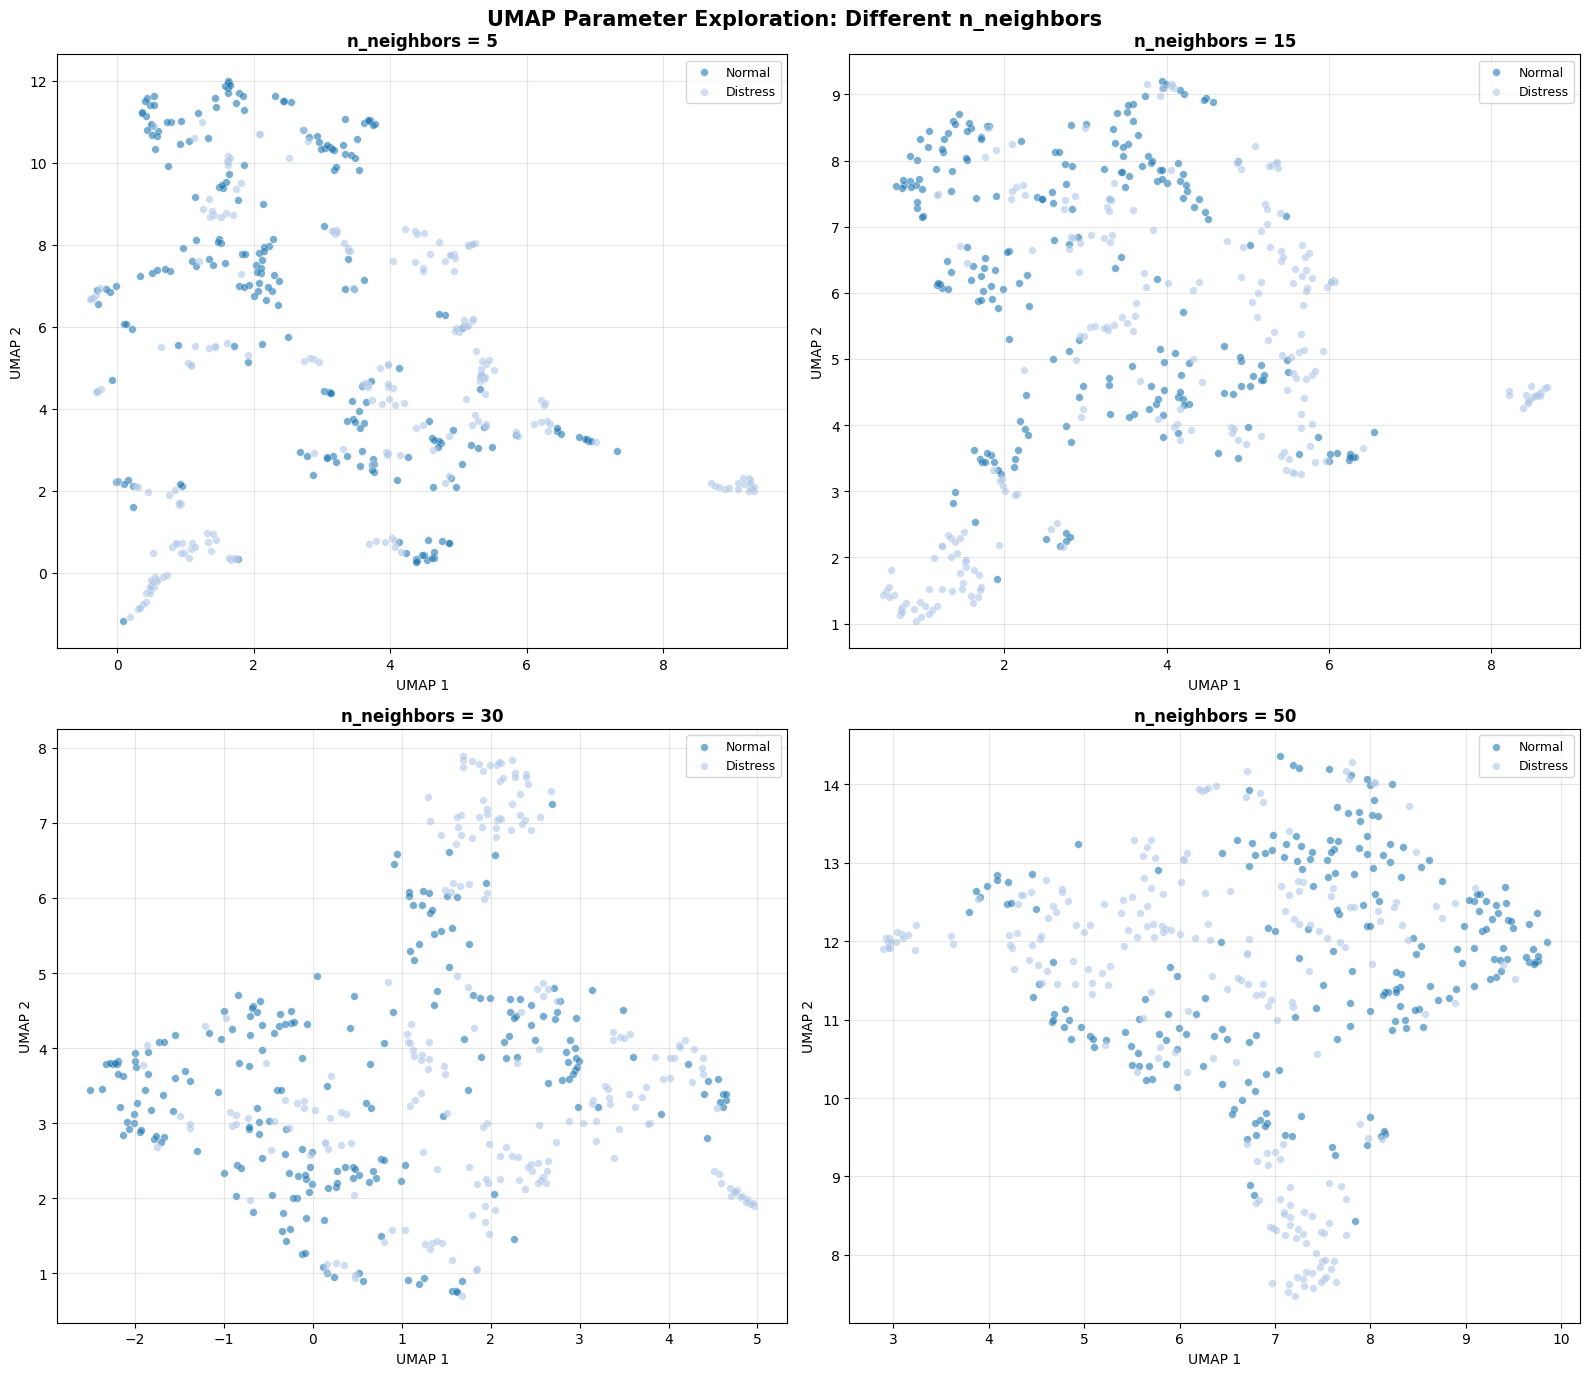

✓ Saved: umap_08_parameter_comparison.png

UMAP ANALYSIS SUMMARY

Clustering Quality:
  Silhouette Score: 0.0783
  (Range: -1 to 1, higher is better)
  Poor separation

Cluster Centers:
  Normal center: (3.02, 6.20)
  Distress center: (3.91, 4.86)
  Separation: 1.61


In [ ]:
# Parameter Exploration: Different UMAP Settings

print("\n" + "=" * 70)
print("VISUALIZATION 8: UMAP PARAMETER COMPARISON")
print("=" * 70)

# Try different n_neighbors values
n_neighbors_values = [5, 15, 30, 50]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, n_neighbors in enumerate(n_neighbors_values):
    print(f"\nRunning UMAP with n_neighbors={n_neighbors}...")

    reducer_temp = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=0.1,
        n_components=2,
        metric='euclidean',
        random_state=42
    )

    X_umap_temp = reducer_temp.fit_transform(X_scaled)

    # Plot
    for label in [0, 1]:
        mask = y == label
        axes[i].scatter(
            X_umap_temp[mask, 0],
            X_umap_temp[mask, 1],
            c=colors[label],
            label=labels_map[label],
            alpha=0.6,
            s=30,
            edgecolors='white',
            linewidth=0.3
        )

    axes[i].set_xlabel('UMAP 1', fontsize=10)
    axes[i].set_ylabel('UMAP 2', fontsize=10)
    axes[i].set_title(f'n_neighbors = {n_neighbors}', fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.3)

plt.suptitle('UMAP Parameter Exploration: Different n_neighbors',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'umap_08_parameter_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: umap_08_parameter_comparison.png")

# Summary Statistics

print("\n" + "=" * 70)
print("UMAP ANALYSIS SUMMARY")
print("=" * 70)

# Overlap analysis - how much do clusters overlap?
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(X_umap, y)

print(f"\nClustering Quality:")
print(f"  Silhouette Score: {silhouette:.4f}")
print(f"  (Range: -1 to 1, higher is better)")

if silhouette > 0.5:
    print(f"  Excellent separation between distress and normal")
elif silhouette > 0.3:
    print(f"  ✓ Good separation")
elif silhouette > 0.1:
    print(f"  Moderate separation")
else:
    print(f"  Poor separation")

print(f"\nCluster Centers:")
print(f"  Normal center: ({normal_center[0]:.2f}, {normal_center[1]:.2f})")
print(f"  Distress center: ({distress_center[0]:.2f}, {distress_center[1]:.2f})")
print(f"  Separation: {separation:.2f}")